From docs at https://pygam.readthedocs.io/en/latest/notebooks/tour_of_pygam.html

In [18]:
import matplotlib.pyplot as plt
import numpy as np
from pygam import LinearGAM, l, f, s
from pygam.datasets import wage

%matplotlib inline

In [5]:
X, y = wage()
X

array([[2.006e+03, 1.800e+01, 0.000e+00],
       [2.004e+03, 2.400e+01, 3.000e+00],
       [2.003e+03, 4.500e+01, 2.000e+00],
       ...,
       [2.005e+03, 2.700e+01, 0.000e+00],
       [2.005e+03, 2.700e+01, 2.000e+00],
       [2.009e+03, 5.500e+01, 1.000e+00]])

In [6]:
gam = LinearGAM(s(0) + s(1) + f(2)).fit(X, y) # f() is for factors
gam.summary()

LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                     25.1911
Link Function:                     IdentityLink Log Likelihood:                                -24118.6847
Number of Samples:                         3000 AIC:                                            48289.7516
                                                AICc:                                           48290.2307
                                                GCV:                                             1255.6902
                                                Scale:                                           1236.7251
                                                Pseudo R-Squared:                                   0.2955
Feature Function                  Lam

/usr/local/lib/python3.6/site-packages/scipy/linalg/basic.py:1321: RuntimeWarning: internal gelsd driver lwork query error, required iwork dimension not returned. This is likely the result of LAPACK bug 0038, fixed in LAPACK 3.2.2 (released July 21, 2010). Falling back to 'gelss' driver.
  x, resids, rank, s = lstsq(a, b, cond=cond, check_finite=False)
/usr/local/lib/python3.6/site-packages/ipykernel_launcher.py:2: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  


In [7]:
gam = LinearGAM(s(0, n_splines=5) + s(1) + f(2)).fit(X, y)
gam.summary()

LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                       22.26
Link Function:                     IdentityLink Log Likelihood:                                -24118.7429
Number of Samples:                         3000 AIC:                                             48284.006
                                                AICc:                                           48284.3852
                                                GCV:                                              1253.479
                                                Scale:                                           1236.7487
                                                Pseudo R-Squared:                                   0.2948
Feature Function                  Lam

/usr/local/lib/python3.6/site-packages/ipykernel_launcher.py:2: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  


In [8]:
# lambda for regularization (on 2nd deriv for smooths, L2 for factor and 
# linear terms)
print(gam.lam) 

[[0.6], [0.6], [0.6]]


In [10]:
lambdas = 3 * np.logspace(-3, 5, 5)
lambdas

array([3.e-03, 3.e-01, 3.e+01, 3.e+03, 3.e+05])

In [12]:
gam.gridsearch(X, y, lam=lambdas)
gam.summary()

LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                     13.9509
Link Function:                     IdentityLink Log Likelihood:                                -24118.8965
Number of Samples:                         3000 AIC:                                            48267.6947
                                                AICc:                                           48267.8545
                                                GCV:                                              1247.246
                                                Scale:                                           1236.8103
                                                Pseudo R-Squared:                                   0.2928
Feature Function                  Lam


/usr/local/lib/python3.6/site-packages/ipykernel_launcher.py:2: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  


In [13]:
list(gam.statistics_.keys())

['n_samples',
 'm_features',
 'edof_per_coef',
 'edof',
 'scale',
 'cov',
 'se',
 'AIC',
 'AICc',
 'pseudo_r2',
 'GCV',
 'UBRE',
 'loglikelihood',
 'deviance',
 'p_values']

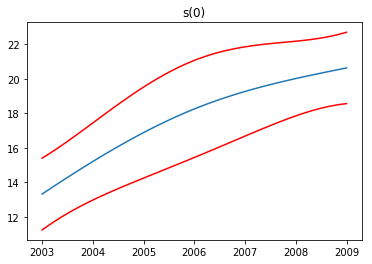

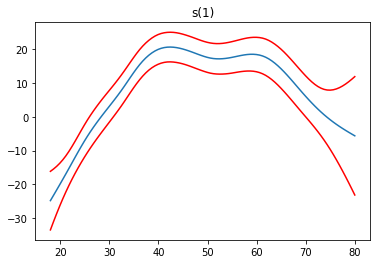

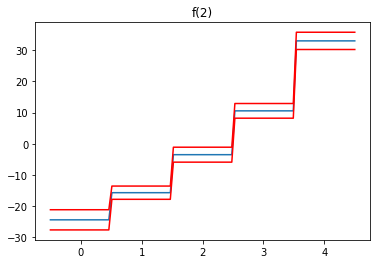

In [15]:
for i, term in enumerate(gam.terms):
    if term.isintercept:
        continue
    XX = gam.generate_X_grid(term=i)
    pdep, conf = gam.partial_dependence(term=i, X=XX, width=0.95)
    plt.figure()
    plt.plot(XX[:, term.feature], pdep)
    plt.plot(XX[:, term.feature], conf, c='r')
    plt.title(repr(term))
    plt.show()

In [19]:
gam = LinearGAM(l(0) + s(1) + f(2)).fit(X, y)
gam.summary()

LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                     20.1985
Link Function:                     IdentityLink Log Likelihood:                                -24118.7177
Number of Samples:                         3000 AIC:                                            48279.8324
                                                AICc:                                           48280.1484
                                                GCV:                                             1251.9007
                                                Scale:                                           1236.7379
                                                Pseudo R-Squared:                                   0.2943
Feature Function                  Lam

/usr/local/lib/python3.6/site-packages/ipykernel_launcher.py:2: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  


In [20]:
gam.gridsearch(X, y, lam=lambdas)
gam.summary()

LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                     13.2422
Link Function:                     IdentityLink Log Likelihood:                                -24119.4387
Number of Samples:                         3000 AIC:                                            48267.3617
                                                AICc:                                           48267.5072
                                                GCV:                                             1246.9374
                                                Scale:                                            1237.034
                                                Pseudo R-Squared:                                   0.2925
Feature Function                  Lam


/usr/local/lib/python3.6/site-packages/ipykernel_launcher.py:2: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  


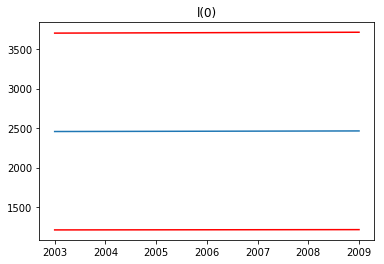

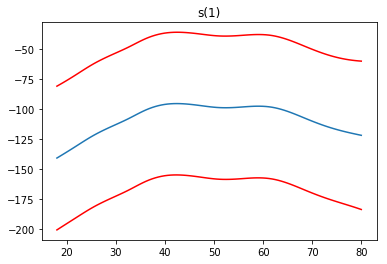

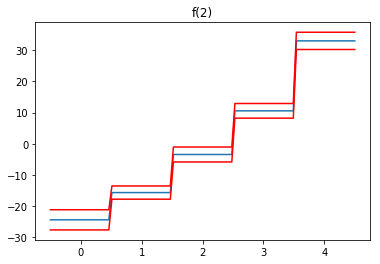

In [21]:
for i, term in enumerate(gam.terms):
    if term.isintercept:
        continue
    XX = gam.generate_X_grid(term=i)
    pdep, conf = gam.partial_dependence(term=i, X=XX, width=0.95)
    plt.figure()
    plt.plot(XX[:, term.feature], pdep)
    plt.plot(XX[:, term.feature], conf, c='r')
    plt.title(repr(term))
    plt.show()